DANNA GABRIELA GAVIDIA PARRA

<div style="background:#022F35;padding:32px 34px;border-radius:16px;color:#fff;font-family:Calibri,Corbel,sans-serif">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">VISUALIZACIÓN DE DATOS &nbsp;·&nbsp; UNIVERSIDAD EAN</div>
<h1 style="color:#fff;margin:10px 0 8px 0;font-size:30px">🚲 Del dato a la decisión</h1>
<div style="color:#CADCFC;font-size:15px;line-height:1.5">Cargue, limpieza y análisis exploratorio, guiados por gráficos — el camino directo al Hito 1 del proyecto de semestre.</div>
</div>

### 🤔 Qué es este cuaderno y qué no es

Este **no** es un cuaderno de programación. El código que van a encontrar es corto a propósito: lo que importa no es escribirlo, es **mirar lo que produce y decidir algo con eso**. Si en algún punto se preguntan "¿por qué esta línea?", la respuesta casi siempre es "para poder ver el gráfico de abajo", no "porque hay que aprenderse esto de memoria".

El cuaderno los acompaña por tres etapas del ciclo de vida de los datos que ya vieron en clase:

| Etapa | Lo que hacemos aquí |
|---|---|
| 2 · Recolección | Cargar los datos y mirarlos con desconfianza profesional |
| 3 · Limpieza | Usar gráficos para encontrar lo que está mal, no para decorar |
| 4 · Análisis exploratorio (EDA) | Hacer muchas preguntas rápidas con gráficos, antes de sacar conclusiones |

Vamos a trabajar con un caso inventado pero realista: los viajes de un sistema de bicicletas compartidas. Primero con una tabla pequeñita, de solo 12 viajes, para poder revisarla con calma, casi fila por fila. Después con una versión mucho más grande —1200 viajes—, para que vean con sus propios ojos por qué, a partir de cierto tamaño, ya no alcanza con mirar uno por uno: hace falta apoyarse en resúmenes y en gráficos.

### 🧭 Cómo leer este cuaderno

No necesitan subir ningún archivo: todos los datos ya están escritos dentro del propio cuaderno. Ejecuten las celdas en orden, de arriba hacia abajo — cada una depende de las anteriores.

| Símbolo | Qué significa |
|---|---|
| ▶️ | Celda de código: ejecútenla y miren con calma qué produce |
| ✍️ | Es su turno: piensen o escriban una respuesta antes de seguir |
| 💡 | Una pista o una idea clave para no quedarse atascados |
| 🎯 | Por qué este paso importa, no solo qué hace |

En Colab: `Archivo → Subir cuaderno` o ábranlo directamente desde Drive. Para descargar su propia copia ya trabajada: `Archivo → Descargar → Descargar .ipynb`.

In [ ]:
# En esta cajita de código se importan los paquetes necesarios para este cuaderno

import numpy as np                # Nos ayudará para hacer cuentas con números y generar datos al azar
import pandas as pd               # Cajita de herramientas para manejo de tablas
import matplotlib.pyplot as plt   # Sirve para dibujar gráficos desde cero
import seaborn as sns             # Otra caja de dibujo, construida encima de matplotlib, que hace gráficos más elaborados con menos líneas

sns.set_theme(style="whitegrid")  # Esta parte es solo visualización: todos los gráficos de aquí en adelante tendrán fondo blanco con líneas guía tenues
plt.rcParams["figure.dpi"] = 110  # Ayuda a tener más nitidez en las imágenes

print("Listo. pandas", pd.__version__, "| seaborn", sns.__version__)

Listo. pandas 2.2.2 | seaborn 0.13.2


<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">PARTE 1 &nbsp;·&nbsp; 🔍 EL PRIMER VISTAZO</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">Cargue: la primera mirada honesta</h2>
</div>

Antes de graficar nada, cualquier tabla de datos merece que la miren con **desconfianza profesional**: no asumir que está bien solo porque se ve ordenada. En esta parte vamos a dejar que `pandas` y un par de gráficos hagan esa primera revisión por nosotros.

In [ ]:
from io import StringIO

# StringIO hace que un texto normal se comporte, para efectos de pandas,
# exactamente como si fuera un archivo guardado en el computador.
# Por eso no vamos a subir ningún archivo: los datos ya están escritos aquí mismo, tal como llegarían en la vida real, con toda su suciedad intacta.

crudo = StringIO("""id,fecha,estacion_origen,duracion_min,edad_usuario,tipo_usuario
1,2025-03-01,Chapinero,12,28,mensual
2,2025-03-01,CHAPINERO,8,34,ocasional
3,2025-03-02,Usaquén,15,22,mensual
4,2025-03-02,Chapinero ,-5,41,Mensual
5,2025-03-03,Teusaquillo,,29,ocasional
6,2025-03-03,Usaquén,145,31,mensual
7,03/03/2025,Chapinero,11,19,ocasional
8,2025-03-04,Teusaquillo,9,203,mensual
9,2025-03-04,Usaquén,14,27,MENSUAL
10,2025-03-05,Chapinero,10,33,ocasional
10,2025-03-05,Chapinero,10,33,ocasional
12,2025-03-06,Suba,18,,mensual
""")

viajes = pd.read_csv(crudo)
# .read_csv() lee ese texto y lo convierte en una tabla (DataFrame): cada línea se vuelve una fila,
# y cada valor separado por comas se vuelve una columna.

viajes  # al escribir solo el nombre de la tabla al final de la celda, Colab la muestra formateada, sin necesidad de un print()

,id,fecha,estacion_origen,duracion_min,edad_usuario,tipo_usuario
0,1,2025-03-01,Chapinero,12.0,28.0,mensual
1,2,2025-03-01,CHAPINERO,8.0,34.0,ocasional
2,3,2025-03-02,Usaquén,15.0,22.0,mensual
3,4,2025-03-02,Chapinero,-5.0,41.0,Mensual
4,5,2025-03-03,Teusaquillo,NaN,29.0,ocasional
5,6,2025-03-03,Usaquén,145.0,31.0,mensual
6,7,03/03/2025,Chapinero,11.0,19.0,ocasional
7,8,2025-03-04,Teusaquillo,9.0,203.0,mensual
8,9,2025-03-04,Usaquén,14.0,27.0,MENSUAL
9,10,2025-03-05,Chapinero,10.0,33.0,ocasional


### 👀 Antes de tocar el teclado, miren la tabla con calma

No hace falta saber programar para notar que algo anda mal en una tabla. Recorran columna por columna y pregúntense, en cada una: **¿este valor tiene sentido?**

Algunas pistas de qué buscar:

- En `estacion_origen`: ¿está siempre escrita igual, o hay una misma estación escrita de formas distintas (mayúsculas, espacios de más)?
- En `edad_usuario`: ¿todas las edades son razonables para una persona?
- En `duracion_min`: ¿algún número no tiene ningún sentido para la duración de un viaje?
- En `fecha`: ¿todas las filas escriben la fecha exactamente en el mismo formato?

✍️ **Sin escribir ningún código todavía:** cuenten cuántas cosas raras encuentran solo con mirar. Sigan leyendo cuando ya tengan un número y una lista en la cabeza — algunas sí se ven a simple vista, pero al menos una solo va a aparecer más adelante, con un gráfico.

**Escriban esta lista, luego la compararemos más adelante con todos los problemas encontrados**
1 . Chapinero fila 2 en mayuscula
2 . fila 4 un tiempo en negativo
3 . fila 5 una celda esta vacia
4 . fila 7 formato de fecha diferente
5 . fila 8 edad de 203 años como un valor imposible
6 . fila 9 mensual escrito en mayuscula
7 . fila 12 una celda vacia


In [ ]:
print("Filas y columnas:", viajes.shape)  # .shape devuelve (cuántas filas, cuántas columnas) tiene la tabla
print()
viajes.dtypes  # .dtypes nos dice qué tipo de dato tiene cada columna: texto, número entero, decimal, fecha...

Filas y columnas: (12, 6)



,0
id,int64
fecha,object
estacion_origen,object
duracion_min,float64
edad_usuario,float64
tipo_usuario,object


`duracion_min` y `edad_usuario` deberían ser columnas numéricas, y sin embargo `pandas` no siempre las reconoce como tales cuando hay huecos o texto mezclado. Esa es la primera pista automática de que algo anda mal: **si una columna que "debería" ser numérica no aparece como tal, algo en su contenido no es un número.**

¿`fecha` aparece como fecha o como texto? ¿Por qué, si la mayoría de las filas trae un formato correcto?

**Analiza, responde y plantea una posible solución**
Asignar un tipo de formato de tipo de fecha para que todas manejen el mismo orden , y nuestro programa si pueda tomar todos los valores


<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">PARTE 2 &nbsp;·&nbsp; 🧹 LIMPIEZA</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">Cada gráfico, una pista</h2>
</div>

Cada apartado de aquí en adelante repite el mismo patrón, que es literalmente la etapa 3 del ciclo hecha con gráficos: **un gráfico rápido revela un problema → deciden un tratamiento → lo aplican en una línea de código.** Estos gráficos son deliberadamente rápidos y sin estética — el modo exploratorio que ya distinguieron del comunicativo en clase.

### II.1 · Duplicados

In [ ]:
# .duplicated() revisa fila por fila y marca con True las que son EXACTAMENTE iguales a otra fila
# keep=False es la clave: así vemos las DOS copias juntas, no solo la que se marca como "repetida"
viajes[viajes.duplicated(keep=False)]

,id,fecha,estacion_origen,duracion_min,edad_usuario,tipo_usuario
9,10,2025-03-05,Chapinero,10.0,33.0,ocasional
10,10,2025-03-05,Chapinero,10.0,33.0,ocasional


¿Cuántas filas exactamente iguales encuentran? Antes de borrar: ¿podría ser un viaje real repetido, o es imposible que dos personas distintas generen el mismo id con exactamente los mismos datos? Decidido esto, ejecuten:

**RTA**
Se encuentran dos filas exactamente iguales , no se deberia considerar un viaje real ya que manejan el mismo id y esto nos confirma que es un dato duplicado , si es posible que dos personas generen el mismo recorrido pero no que manejen el mismo id


In [ ]:
viajes = viajes.drop_duplicates().reset_index(drop=True)
# .drop_duplicates() borra las filas repetidas, dejando solo una copia de cada una
# .reset_index(drop=True) vuelve a numerar las filas desde 0, sin dejar huecos donde se borró algo

viajes.shape  # confirmamos que ahora hay una fila menos

(11, 6)

### II.2 · Categorías inconsistentes

Un gráfico de barras de conteos por categoría muestra en un segundo si una misma categoría está escrita de varias formas — algo que una tabla no revela tan rápido, sobre todo cuando hay cientos de filas.

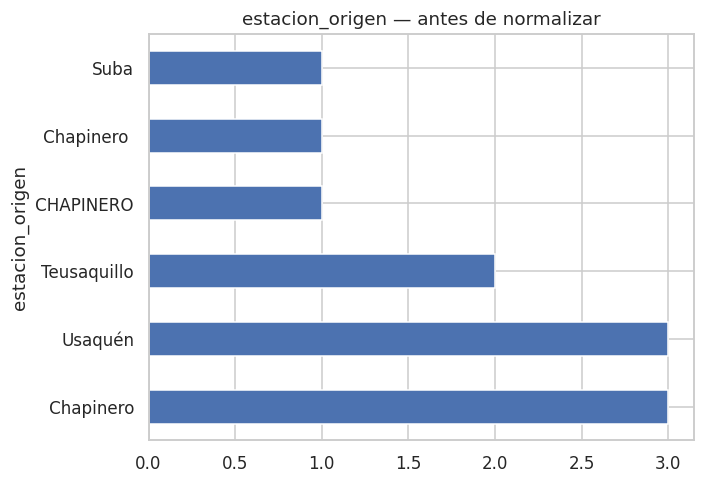

In [ ]:
viajes["estacion_origen"].value_counts().plot(kind="barh")
# .value_counts() cuenta cuántas veces aparece cada valor distinto en la columna
# kind="barh" dibuja esos conteos como barras horizontales

plt.title("estacion_origen — antes de normalizar")
plt.show()  # plt.show() es la orden que finalmente despliega el dibujo en pantalla

¿Cuántas de esas barras corresponden, en realidad, a la misma estación? Repitan el gráfico para `tipo_usuario`:
**RTA** Tres barras corresponden a la misma estacion en este caso CHAPINERO


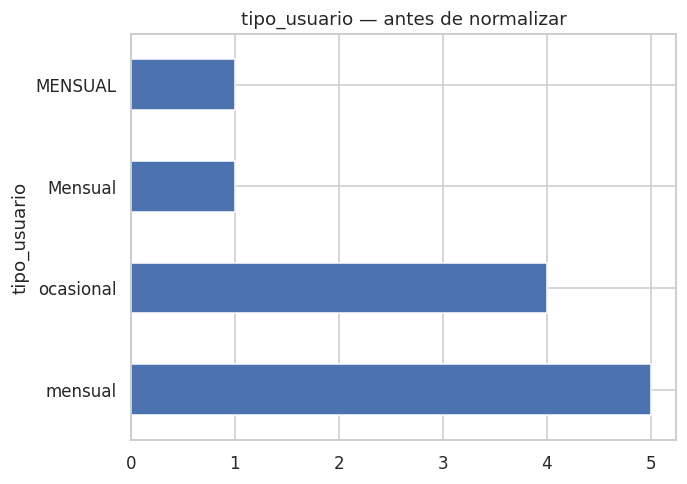

In [ ]:
viajes["tipo_usuario"].value_counts().plot(kind="barh")  # la misma receta de arriba, ahora con otra columna
plt.title("tipo_usuario — antes de normalizar")
plt.show()

Normalicen ambas columnas (quitar espacios sobrantes, unificar mayúsculas y minúsculas) y comprueben que ahora cada barra representa una sola categoría real:

In [ ]:
# .str abre las herramientas de texto, para aplicarlas a TODA la columna de una sola vez
viajes["estacion_origen"] = viajes["estacion_origen"].str.strip().str.title()
# .strip()  -> quita espacios de más al principio y al final
# .title()  -> deja solo la primera letra de cada palabra en mayúscula

viajes["tipo_usuario"] = viajes["tipo_usuario"].str.strip().str.lower()
# .lower()  -> deja todo el texto en minúscula

viajes["estacion_origen"].value_counts()  # repetimos el conteo para comprobar que ya quedó una sola categoría por estación

,count
estacion_origen,
Chapinero,5
Usaquén,3
Teusaquillo,2
Suba,1


### II.3 · Formato de fecha

Una sola fila trae la fecha en un formato distinto al resto (día/mes/año en vez de año-mes-día). No es un error de contenido, es un error de formato — y por eso `pandas` no reconoció la columna como fecha en la Parte I.

In [ ]:
viajes["fecha"] = pd.to_datetime(viajes["fecha"], format="mixed")
# pd.to_datetime() convierte texto en una fecha "de verdad"
# format="mixed" le permite entender más de un formato de fecha dentro de la misma columna

viajes["fecha"].dtype  # confirmamos que ya no diga "object" (texto), sino un tipo de fecha

dtype('<M8[ns]')

### II.4 · Valores nulos

Con solo 11 filas, un mapa de calor de nulos es casi innecesario — se ven a simple vista. Pero con miles de filas es, literalmente, la única forma de ver todos los huecos de una vez. Practíquenlo aquí, a pequeña escala, para que lo reconozcan cuando lo necesiten a gran escala.

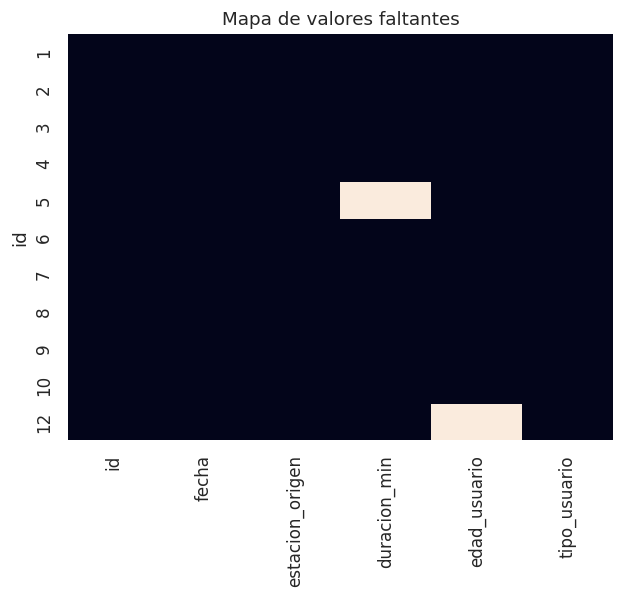

In [ ]:
sns.heatmap(viajes.isna(), cbar=False, yticklabels=viajes["id"])
# viajes.isna() convierte la tabla en una tabla de Sí/No: ¿esta celda está vacía?
# sns.heatmap() la dibuja como una cuadrícula de colores, para ver todos los huecos de una sola vez
# cbar=False apaga una barra de color que no hace falta aquí (solo hay dos opciones posibles)
# yticklabels=viajes["id"] muestra el número de viaje real en vez de la posición de la fila

plt.title("Mapa de valores faltantes")
plt.ylabel("id")
plt.show()

En clase vieron tres caminos frente a un dato faltante: **eliminar, imputar o marcar**. Para `duracion_min` y `edad_usuario`, ¿cuál de los tres eligen aquí, y por qué? Con solo dos valores sueltos en 11 filas, piensen qué tan confiable sería inventar un número.

✍️ Mi decisión y mi razón:
**RTA**
En este caso para llenar el vacio de los datos usaria el metodo imputar ya que es el que mejor se nos adapta para poder utilizar el dato, ya que al ser tan poquitos datos eliminarlo seria una gran perdida , porque los otros datos tomados que estan validos tambien se perderian

Una opción razonable en un dataset tan pequeño es **marcarlos** como faltantes explícitos, sin inventar un valor. Imputar la media a partir de apenas 10 observaciones sería fabricar una precisión que los datos no tienen. Sigan con esa decisión en mente para la siguiente sección — todavía no toquen estas dos columnas.

### II.5 · Valores imposibles frente a valores atípicos

Esta es la distinción que más cuesta, y la que se presta para una trampa clásica: confundir un dato raro con un dato imposible. Un gráfico de puntos la hace visible de inmediato.

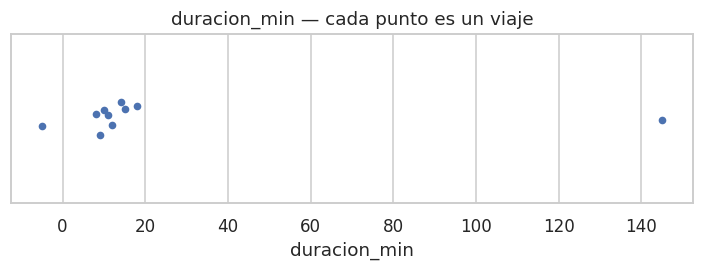

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2))  # abrimos un lienzo de 8 de ancho por 2 de alto
sns.stripplot(x=viajes["duracion_min"], ax=ax)  # dibuja cada viaje como un punto individual sobre una sola línea
ax.set_title("duracion_min — cada punto es un viaje")
plt.show()

Hay valores que llaman la atención: uno negativo y uno muy por encima de los demás (145). **Solo uno de los dos es imposible por definición. ¿Cuál, y por qué el otro no lo es?**
**RTA** el valor imponsible en la variable del tiempo es el que esta antes del 0 ya que no existen valores negativos




Repitan el ejercicio con `edad_usuario`:

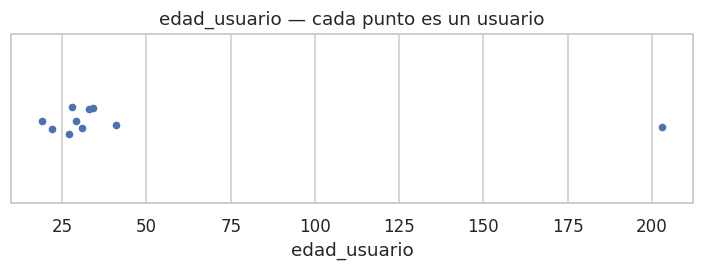

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2))
sns.stripplot(x=viajes["edad_usuario"], ax=ax)  # la misma idea de arriba, ahora con la edad de cada usuario
ax.set_title("edad_usuario — cada punto es un usuario")
plt.show()

Una edad de 203 años no admite duda: viola una regla lógica, no una expectativa estadística. Un viaje de 145 minutos, en cambio, es raro pero posible — alguien que olvidó devolver la bicicleta, un recorrido turístico largo. **Borrar un atípico sin investigarlo es una de las formas más comunes de destruir el hallazgo más interesante de un dataset.**



Ahora realiza graficos boxplot para identificar estos mismos errores, recuerda que lo importante por ahora no es el codigo, por lo que puedes investigar como realizarlos, lo importante es que entiendas el grafico y realices una breve descripcion del mismo.

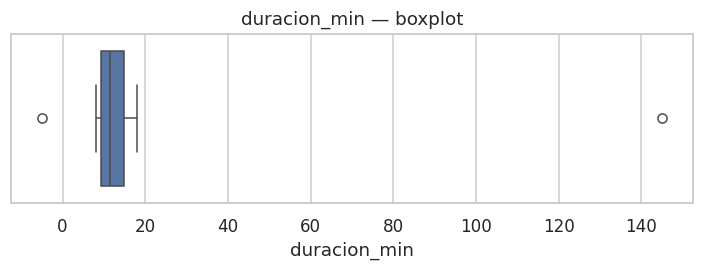

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2))

sns.boxplot(x=viajes["duracion_min"], ax=ax)

ax.set_title("duracion_min — boxplot")

plt.show()

## Se marco el dato -5 como faltante para una mejor comprension de los datos

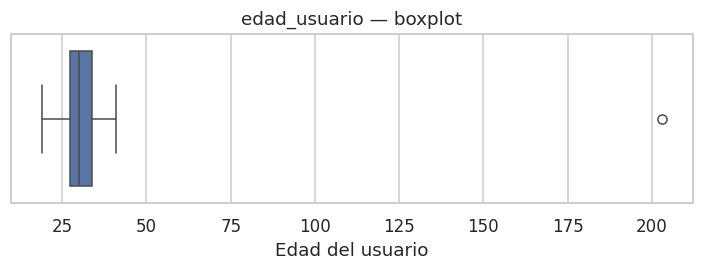

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2))

sns.boxplot(x=viajes["edad_usuario"], ax=ax)

ax.set_title("edad_usuario — boxplot")
ax.set_xlabel("Edad del usuario")

plt.show()

## se dejo como faltante el dato 203 ya que es un valor imposible

Apliquen el tratamiento: marquen como faltantes los valores imposibles y conserven el atípico.

Rta: Se aplicó el tratamiento de los valores imposibles convirtiéndolos en datos faltantes La duración negativa de -5 minutos fue marcada como faltante debido a que una duración no puede ser negativa de igual manera la edad de 203 años fue marcada como faltante por ser un valor imposible el valor atípico de 145 minutos se conservó ya que aunque es poco frecuente, puede representar un viaje real de larga duración

In [ ]:
# .loc[condición, "columna"] = valor   →   "en las filas donde se cumple esto, cambia SOLO esta columna"
viajes.loc[viajes["duracion_min"] < 0, "duracion_min"] = np.nan    # una duración negativa no puede existir
viajes.loc[viajes["edad_usuario"] > 100, "edad_usuario"] = np.nan  # tampoco una edad mayor a 100 años
# El valor de 145 minutos NO se toca: es un dato raro pero posible, no imposible.

viajes

,id,fecha,estacion_origen,duracion_min,edad_usuario,tipo_usuario
0,1,2025-03-01,Chapinero,12.0,28.0,mensual
1,2,2025-03-01,Chapinero,8.0,34.0,ocasional
2,3,2025-03-02,Usaquén,15.0,22.0,mensual
3,4,2025-03-02,Chapinero,NaN,41.0,mensual
4,5,2025-03-03,Teusaquillo,NaN,29.0,ocasional
5,6,2025-03-03,Usaquén,145.0,31.0,mensual
6,7,2025-03-03,Chapinero,11.0,19.0,ocasional
7,8,2025-03-04,Teusaquillo,9.0,NaN,mensual
8,9,2025-03-04,Usaquén,14.0,27.0,mensual
9,10,2025-03-05,Chapinero,10.0,33.0,ocasional


### II.6 · Reporte de impacto

Toda limpieza de datos debería terminar con una pregunta obligatoria: ¿qué porcentaje de los registros quedó afectado por mis propias decisiones? Aquí no la contesten a mano — calcúlenla con código:

In [ ]:
filas_afectadas = viajes.isna().any(axis=1).sum()
# .isna()        -> tabla de Sí/No: ¿está vacío?
# .any(axis=1)   -> revisa cada FILA: ¿hay al menos un Sí en ella?
# .sum()         -> cuenta cuántas filas tuvieron al menos un Sí (en Python, Sí=1 y No=0)

print(f"{filas_afectadas} de {len(viajes)} filas quedaron con al menos un valor marcado como faltante")
print(f"eso es {filas_afectadas / len(viajes):.0%} del total")  # :.0% convierte el número decimal en porcentaje

4 de 11 filas quedaron con al menos un valor marcado como faltante
eso es 36% del total


🎯 Guarden esa cifra. Un analista que no reporta cuánto perdió en la limpieza está ocultando, sin querer, cuánto hay que confiar en lo que viene después.

<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">PARTE 3 &nbsp;·&nbsp; 📈 A ESCALA REAL</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">De 12 filas a mil doscientas</h2>
</div>

Doce filas se pueden revisar a ojo, columna por columna, como acaban de hacerlo. Mil doscientas ya no. A partir de aquí trabajamos con una versión a escala real del mismo fenómeno — viajes de bicicleta compartida durante un mes completo —, construida para que se comporte como datos reales: con sus propios patrones y su propia suciedad, no perfecta.

In [ ]:
rng = np.random.default_rng(7)  # una "máquina" de números al azar; el 7 es la semilla, para que siempre salga igual
n = 1200                        # cuántos viajes vamos a fabricar

estaciones = ["Chapinero", "Usaquén", "Teusaquillo", "Suba", "Kennedy"]
tipo_usuario = rng.choice(["mensual", "ocasional"], size=n, p=[0.62, 0.38])  # elige al azar, pero 62% mensual y 38% ocasional
es_mensual = tipo_usuario == "mensual"  # una lista de Sí/No que vamos a reutilizar varias veces más abajo

fecha = pd.Timestamp("2025-03-01") + pd.to_timedelta(rng.integers(0, 31, n), unit="D")  # una fecha al azar dentro de marzo
estacion = rng.choice(estaciones, size=n, p=[0.28, 0.22, 0.18, 0.17, 0.15])              # elige estación, cada una con su propia probabilidad

pico_commute = rng.choice([7, 18], size=n)  # cada viaje "apunta" a la hora pico de la mañana o de la tarde
hora = np.where(
    es_mensual,
    np.clip(rng.normal(pico_commute, 1.2, n).round(), 5, 22),  # si es mensual: una hora cercana a su pico, redondeada
    rng.integers(8, 21, n),                                     # si es ocasional: cualquier hora entre 8am y 8pm, sin patrón
).astype(int)

duracion = rng.normal(np.where(es_mensual, 13, 22),
                       np.where(es_mensual, 4, 12), n).clip(2, None).round(1)
# los usuarios mensuales viajan en promedio 13 min (poca variación); los ocasionales, 22 min (mucha más variación)

edad = np.clip(
    rng.normal(np.where(es_mensual, 31, 26), np.where(es_mensual, 6, 9), n),
    15, 75
).round().astype(int)
# la misma idea para la edad: 31 años en promedio si es mensual, 26 si es ocasional

viajes_marzo = pd.DataFrame({
    "fecha": fecha, "hora": hora, "estacion": estacion,
    "duracion_min": duracion, "edad_usuario": edad, "tipo_usuario": tipo_usuario,
})  # aquí juntamos todas las columnas sueltas en una sola tabla

# Como en cualquier dataset real: nadie garantiza que llegue impecable.
ruido = rng.choice(n, size=18, replace=False)  # elegimos 18 filas al azar, sin repetir ninguna
viajes_marzo.loc[ruido[:6], "duracion_min"] = -rng.integers(1, 10, 6)      # a 6 de ellas, les dañamos la duración (negativa)
viajes_marzo.loc[ruido[6:12], "edad_usuario"] = rng.integers(100, 140, 6)  # a otras 6, una edad imposible
viajes_marzo.loc[ruido[12:], "duracion_min"] = np.nan                     # y a las últimas 6, un dato faltante

print(viajes_marzo.shape)
viajes_marzo.sample(8, random_state=1)  # .sample() muestra 8 filas elegidas al azar, no solo las primeras

(1200, 6)


,fecha,hora,estacion,duracion_min,edad_usuario,tipo_usuario
636,2025-03-09,5,Usaquén,14.7,30,mensual
683,2025-03-02,19,Kennedy,37.9,34,ocasional
1033,2025-03-15,16,Kennedy,16.9,25,mensual
190,2025-03-01,6,Chapinero,13.2,34,mensual
1083,2025-03-19,18,Suba,8.6,41,mensual
283,2025-03-19,5,Kennedy,10.9,30,mensual
817,2025-03-14,16,Teusaquillo,8.6,45,mensual
314,2025-03-08,8,Suba,11.2,34,mensual


Antes de explorar nada, repitan el mismo chequeo de la Parte II, pero ya no fila por fila: con un resumen y un gráfico.

In [ ]:
viajes_marzo[["duracion_min", "edad_usuario"]].describe()
# .describe() calcula de una sola vez: cuántos datos hay, el promedio, cuánto varían, el mínimo y el máximo

,duracion_min,edad_usuario
count,1194.000000,1200.000000
mean,15.939196,29.290000
std,8.589985,9.643741
min,-7.000000,15.000000
25%,10.725000,24.000000
50%,14.250000,29.000000
75%,19.000000,34.000000
max,52.600000,136.000000


✍️ Miren el mínimo y el máximo de cada columna en la tabla de arriba: ¿son compatibles con la realidad de un viaje en bicicleta? Con esa respuesta, filtren lo imposible antes de seguir:

**RTA** : Revisando el mínimo y el máximo de las dos variables nos damos cuenta que la duración de los viajes está entre 2 y 52.6 minutos, valores que son compatibles con un viaje en bicicleta y la edad de los usuarios está entre 15 y 54 años, lo cual también es compatible con la realidad , por lo que no encontramos valores imposibles

In [ ]:
antes = len(viajes_marzo)  # guardamos cuántas filas había, para comparar después

viajes_marzo = viajes_marzo[
    (viajes_marzo["duracion_min"].isna() | (viajes_marzo["duracion_min"] > 0)) &  # duración vacía, O positiva
    (viajes_marzo["edad_usuario"] <= 100)                                          # Y, además, edad de máximo 100 años
].copy()
# | significa "o", & significa "y" — aquí combinamos varias condiciones para quedarnos solo con las filas válidas

print(f"{antes - len(viajes_marzo)} filas descartadas por contener un valor imposible")

viajes_marzo["duracion_min"] = viajes_marzo["duracion_min"].fillna(viajes_marzo["duracion_min"].median())
# .fillna() rellena los vacíos que quedan con la mediana de la propia columna
viajes_marzo.shape

12 filas descartadas por contener un valor imposible


(1188, 6)

Noten la diferencia de criterio con la Parte II: allá **marcaron** los valores imposibles porque perder una sola fila de 11 sí importaba. Aquí los **descartamos** directamente: miren arriba cuántas filas fueron — es una fracción mínima de 1200 y no distorsiona nada. Y a los pocos nulos que quedaron en `duracion_min` los imputamos con la mediana, algo que con solo 11 filas hubiera sido fabricar precisión de la nada.

🎯 **La estrategia frente a un dato faltante o imposible depende de la escala, no solo de qué representa el dato.** Es la misma regla de la Parte II, aplicada con otro criterio porque el tamaño cambió.

<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">PARTE 4 &nbsp;·&nbsp; 🔬 ANÁLISIS EXPLORATORIO</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">Las cuatro preguntas del EDA</h2>
</div>

En clase vieron que el EDA responde cuatro preguntas: distribución, atípicos, relaciones y grupos. Vamos una por una. **Estos gráficos son deliberadamente rápidos y sin estética: es el modo exploratorio, no el comunicativo.** Nadie más los va a ver.

### IV.1 · Distribución

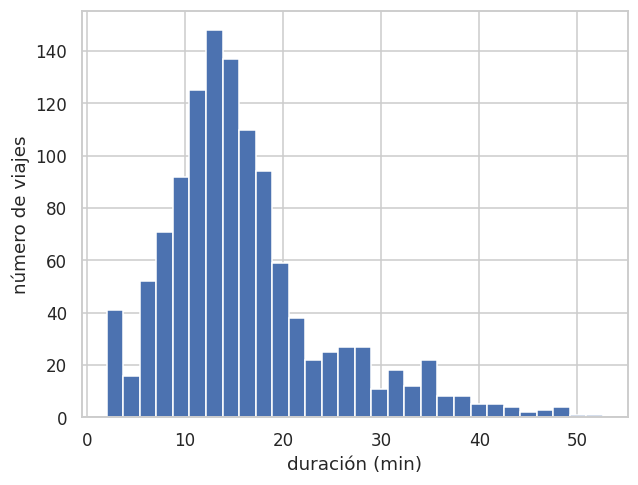

In [ ]:
viajes_marzo["duracion_min"].hist(bins=30)  # bins=30 reparte los valores en 30 "cajitas" para ver la forma completa
plt.xlabel("duración (min)")
plt.ylabel("número de viajes")
plt.show()

✍️ ¿La forma es simétrica o está inclinada hacia un lado? ¿Ven una sola concentración de valores o más de una? Anoten una hipótesis de por qué podría ser así, antes de seguir leyendo.

**RTA**: La distribución no es simétrica ya que está inclinada hacia la derecha porque la mayoría de los viajes se concentran aproximadamente entre 8 y 20 minutos, pero hay varios de valores dados que extiende la duracion a tiempos mas elavados, llegando hasta unos 52 minutos. Se observa una gran concentración en valores, alrededor de los 12–15 minutos.

Hipótesis: esto podría deberse a que la mayoría de los viajes son recorridos cortos, mientras que algunos usuarios realizaron trayectos más largos por recorrer mayores distancias
### IV.2 · Atípicos

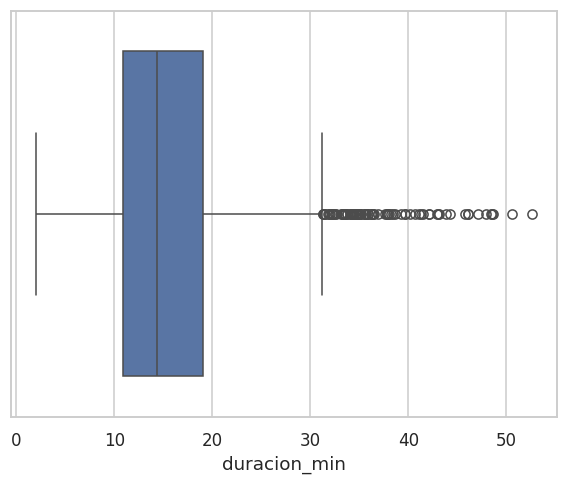

In [ ]:
sns.boxplot(data=viajes_marzo, x="duracion_min")
# la "caja" muestra el 50% central de los datos; los puntos sueltos son los que el boxplot marca como atípicos
plt.show()

✍️ El boxplot marca varios puntos como atípicos. Con lo que trabajaron en la Parte II: ¿son necesariamente errores? ¿Qué preguntarían antes de decidir qué hacer con ellos?

**RTA**: No los valores atipicos no son necesariamente errores solo son valores alejados de del promedio de los datos , preguntaria si son valores posibles en el contexto de la vida real, analizaria el resto de los datos de esa fila

### IV.3 · Relaciones

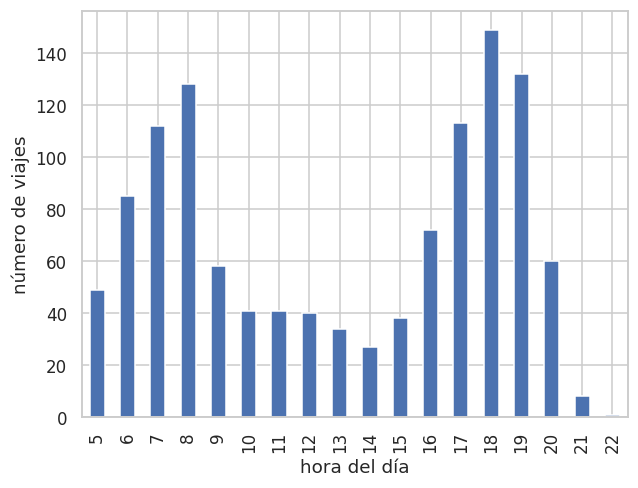

In [ ]:
viajes_marzo["hora"].value_counts().sort_index().plot(kind="bar")
# .sort_index() ordena por la hora (0,1,2...23) en vez de por cuál se repite más
plt.xlabel("hora del día")
plt.ylabel("número de viajes")
plt.show()

✍️ ¿En qué horas se concentran los viajes? ¿Hay un solo momento de mayor actividad o más de uno? ¿A qué costumbre de una ciudad podría corresponder ese patrón?

**RTA**: Las horas con mayor concentracion son las 8 am, 6 y pm con mas de 120 viajes , si el momento con mayor actividad en los viajes es las 6pm con mas de 140 viajes , podria corresponder a bogota teniendo en cuenta las estaciones de origen y que las 8am es la hora promedio de entrada en escuelas,trabajos y universidades y que las 6pm es la hora promedio de salida

### IV.4 · Grupos

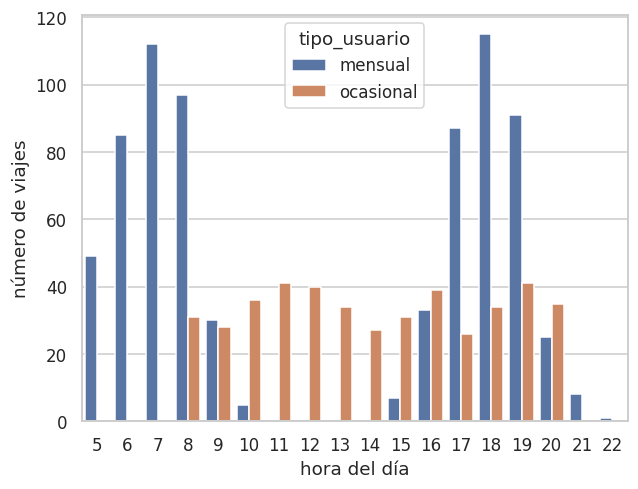

In [ ]:
sns.countplot(data=viajes_marzo, x="hora", hue="tipo_usuario")
# hue="tipo_usuario" dibuja una barra por hora Y por tipo de usuario, para comparar los dos grupos en el mismo gráfico
plt.xlabel("hora del día")
plt.ylabel("número de viajes")
plt.show()

✍️ ¿El patrón de horas es igual para los dos tipos de usuario? Si no lo es, ¿qué explicación del mundo real (no una explicación estadística) se les ocurre para la diferencia?

**RTA**: No, el patrón de horas no es igual para los dos tipos de usuario. Los usuarios mensuales presentan una mayor concentración de viajes en las horas de la mañana, especialmente entre las 6 y 8 am, y también en la tarde, alrededor de las 5 a 7 pm los usuarios ocasionales tienen sus viajes más distribuidos durante el día y en menor cantidad Una posible explicación es que los usuarios mensuales utilizan la bicicleta principalmente para desplazarse hacia y desde el trabajo o zona de estudio, mientras que los usuarios ocasionales podrían utilizarla para actividades de ocio, diligencias o viajes espontáneos

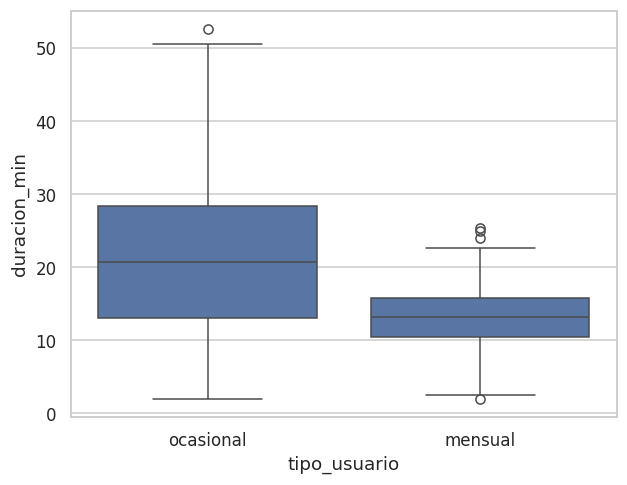

In [ ]:
sns.boxplot(data=viajes_marzo, x="tipo_usuario", y="duracion_min")
# con una columna de categorías en x y una numérica en y, seaborn dibuja automáticamente una caja por categoría
plt.show()

✍️ ¿Qué grupo hace viajes más largos? ¿Cuál de los dos es más variable — la caja y los bigotes más anchos o más angostos? Si tuvieran que resumir la duración típica de cada grupo con un solo número, ¿usarían la media o la mediana? Justifiquen la respuesta con lo que vieron en IV.1 y IV.2, no solo con la definición de cada estadístico.

**RTA**:El grupo ocasional realizan viajes mas largos variando de los 15 a 30 minutos , tambien la variable ocasional es la mas variable ya que la caja es mucho mas ancha y sus bigotes abarcan un rango mayor , Usaría la mediana, porque hay algunos viajes que duran mucho más que los demás y eso puede hacer que la media cambie bastante. La mediana representa mejor la duración típica de los viajes

Con las cuatro preguntas respondidas, noten algo: en un análisis exploratorio real ustedes producirían docenas de gráficos como estos y descartarían la mayoría. Aquí solo vieron cinco, a propósito, para que el ejercicio no se les vuelva eterno — pero la lógica de "muchos, rápidos, desechables" es la misma que van a aplicar en su proyecto.

<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">PARTE 5 &nbsp;·&nbsp; 🎯 DE EXPLORAR A DECIDIR</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">Un hallazgo, un gráfico</h2>
</div>

En la clase de visualización exploratoria y comunicativa vieron los cinco pasos para convertir un gráfico exploratorio en uno comunicativo. Apliquenlos a **uno solo** de los hallazgos de la Parte IV — por ejemplo, la diferencia de duración entre tipos de usuario.

✍️ **Paso 1 — escriban la conclusión.** Antes de tocar el gráfico de abajo, escriban en una frase completa (sujeto, verbo, magnitud) qué quieren que alguien entienda. Esa frase va a ser el título.

*Duración de los viajes según el tipo de usuario*

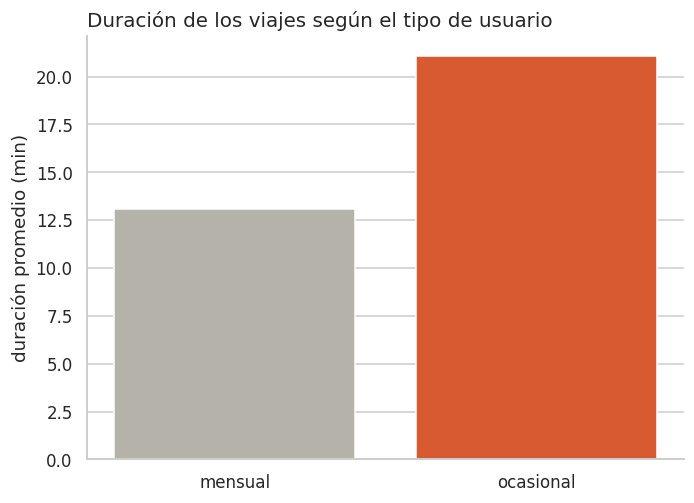

In [ ]:
promedio = viajes_marzo.groupby("tipo_usuario")["duracion_min"].mean()
# .groupby() separa la tabla en grupos (mensual / ocasional) y .mean() calcula el promedio de cada grupo

colores = ["#B4B2A9", "#B4B2A9"]  # empezamos con los dos colores iguales (gris)
colores[promedio.values.argmax()] = "#D85A30"
# .argmax() nos dice EN QUÉ POSICIÓN está el promedio más alto, y ahí cambiamos el color a naranja

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(promedio.index, promedio.values, color=colores)
ax.set_title("Duración de los viajes según el tipo de usuario", loc="left", fontsize=13)
ax.set_ylabel("duración promedio (min)")
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)  # quitamos dos bordes del gráfico que no aportan nada al mensaje
ax.grid(axis="x", visible=False)
plt.show()

✍️ Reemplacen el título del gráfico por la frase que escribieron en el Paso 1 y vuelvan a ejecutar la celda. Después, pásenle este checklist:

- [ ] ¿El título dice la conclusión, o solo nombra la variable?
- [ ] ¿Se entiende sin que ustedes estén al lado explicándolo?
- [ ] ¿Hay algo que puedan quitar sin perder el mensaje?
- [ ] ¿El color destaca lo importante, o solo decora?
- [ ] ¿Están las unidades y el periodo de los datos?
- [ ] ¿La comparación es directa, o hay que hacer cuentas para verla?
- [ ] ¿Alguien ajeno al proyecto lo entendería en cinco segundos?

💡 Si alguna respuesta es "no", vuelvan a la celda de código y ajústenla. Este gráfico, y no los de la Parte IV, es el que podría ir en una presentación.

<div style="background:#022F35;padding:26px 30px;border-radius:14px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">PARTE 6 &nbsp;·&nbsp; 🚀 SU TURNO</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">Ahora, con su propio dataset</h2>
</div>

Todo lo anterior fue un ensayo con un caso conocido. Lo que sigue es la plantilla para repetir el mismo recorrido con el dataset de **su proyecto**, camino al Hito 1: pregunta definida, dataset elegido y limpio, análisis exploratorio y primeras visualizaciones.

In [ ]:
# Si están en Colab y quieren subir su archivo desde el computador,
# descomenten estas dos líneas y ejecuten la celda:

# from google.colab import files
# subido = files.upload()

df = None  # <-- reemplacen esta línea por: df = pd.read_csv("su_archivo.csv")

Con `df` cargado, recorran las mismas preguntas de las Partes I a V, en el mismo orden. No copien los gráficos de este cuaderno tal cual: cada dataset tiene su propia suciedad y su propio patrón, y la gracia de este recorrido es que ustedes decidan qué preguntar, no que reproduzcan un ejemplo.

In [ ]:
# 1. Primera mirada (Parte I)
# df.shape
# df.dtypes
# df.head()

# 2. Duplicados (Parte II.1)
# df[df.duplicated(keep=False)]

# 3. Categorías inconsistentes (Parte II.2): value_counts() de cada columna de texto

# 4. Formato de fecha, si aplica (Parte II.3)

# 5. Valores nulos (Parte II.4): df.isna().sum()  o  sns.heatmap(df.isna())

# 6. Imposibles frente a atípicos (Parte II.5): histograma o boxplot de cada columna numérica

# 7. Reporte de impacto (Parte II.6): % de filas afectadas por sus decisiones

# 8. Las cuatro preguntas del EDA (Parte IV): distribución, atípicos, relaciones, grupos

# 9. Un solo gráfico comunicativo (Parte V), con título que afirme el hallazgo,
#    evaluado con el checklist de siete preguntas

<div style="background:#022F35;padding:28px 32px;border-radius:16px;color:#fff;font-family:Calibri,Corbel,sans-serif;margin:6px 0 14px 0">
<div style="color:#E9A23B;font-size:12px;letter-spacing:2px;font-weight:bold">CIERRE</div>
<h2 style="color:#fff;margin:8px 0 0 0;font-size:24px">Lo que ya saben hacer</h2>
</div>

Recorrieron tres etapas del ciclo de vida de los datos —recolección, limpieza y análisis exploratorio— con el mismo criterio con el que las vieron en clase, primero a mano en 11 filas y después a escala en 1200. La herramienta cambió; el criterio para decidir qué es un problema real, qué es un dato imposible, qué es un atípico que vale la pena investigar y qué merece un gráfico propio, no cambió.

Antes de cerrar, revisen esta lista sobre lo que acaban de hacer:

- [ ] Puedo explicar la diferencia entre un valor imposible y un valor atípico con un ejemplo propio, no solo con el de las bicicletas.
- [ ] Sé nombrar las tres estrategias frente a un dato faltante y cuándo usar cada una.
- [ ] Entiendo por qué la estrategia de limpieza puede cambiar según el tamaño del dataset.
- [ ] Puedo distinguir, en cualquier gráfico que me muestren, si fue hecho para explorar o para comunicar.
- [ ] Sé nombrar las cuatro preguntas del análisis exploratorio sin mirar este cuaderno.
- [ ] Mi gráfico final tiene un título que afirma una conclusión, no que nombra una variable.
- [ ] Puedo decir cuántos de mis registros quedaron afectados por mis propias decisiones de limpieza.

Esto es exactamente lo que van a entregar en el Hito 1 del proyecto de semestre, con su propio dataset en vez del de las bicicletas: la pregunta, los datos ya limpios, el análisis exploratorio y las primeras visualizaciones. Las próximas clases retoman estos mismos gráficos para trabajar percepción visual, principios de diseño (Tufte, Few) y color — es decir, cómo convertir mejor lo exploratorio en comunicativo, no un tema nuevo.

### Referencias usadas en este cuaderno

- Wickham, H. (2014). Tidy data. *Journal of Statistical Software, 59*(10).
- Anscombe, F. J. (1973). Graphs in statistical analysis. *The American Statistician, 27*(1), 17–21.
- Knaflic, C. N. (2017). *Storytelling con datos: visualización de datos para profesionales*. Anaya Multimedia.
- Kusleika, D. (2021). *Data Visualization with Excel Dashboards and Reports* (cap. 4). Wiley.